In [ ]:
import pandas as pd
# dados normalizados sem outliers
df = pd.read_parquet("../df_normal.parquet")

PCA 2 Componentes

Explained variance ratio:
[0.21690002 0.12937801]

Total explained variance:
0.34627803142673524


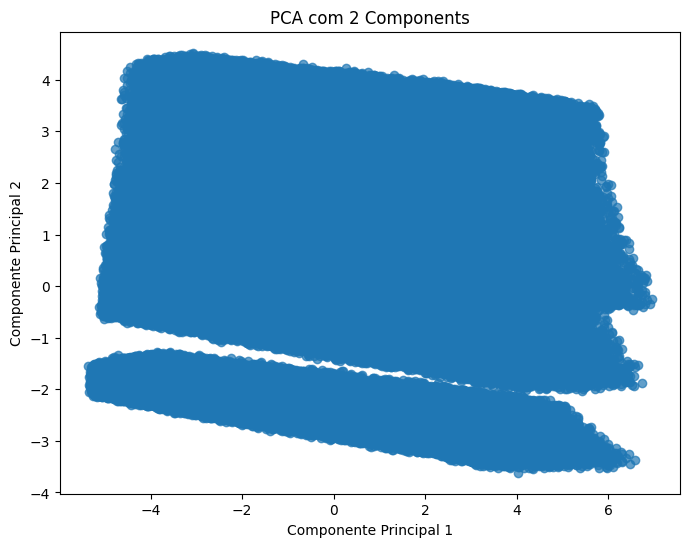

In [3]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA 
X = df.select_dtypes(include=["number"])

# PCA com 2 componentes
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

# DataFrame com os componentes principais
df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

# Variância explicada
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance:")
print(pca.explained_variance_ratio_.sum())

# Visualização
plt.figure(figsize=(8,6))

plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    alpha=0.7
)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("PCA com 2 Components")

plt.show()

Modelo PCA


In [ ]:
import joblib

pca = joblib.load("../Modelos/pca_model.pkl")

In [12]:
import numpy as np
print("\nRazão da variância explicada por componente:\n")
print(pca.explained_variance_ratio_)
print("\nVariância Explicada Acumulada:\n")
print(np.cumsum(pca.explained_variance_ratio_))
print("\nNúmero de Componentes:\n")
print(pca.n_components)
print("\nValores Singulares:\n")
print(pca.singular_values_)
print("\nComponente Principais (direções):\n")
print(pca.components_)


Razão da variância explicada por componente:

[0.21690002 0.12937801 0.09223913 0.04926346 0.04840583 0.04100065
 0.04075093 0.04019317 0.03965389 0.03828762 0.0373185  0.03646747
 0.03603167 0.03518053 0.03249752]

Variância Explicada Acumulada:

[0.21690002 0.34627803 0.43851716 0.48778062 0.53618645 0.57718709
 0.61793803 0.65813119 0.69778508 0.7360727  0.7733912  0.80985868
 0.84589035 0.88107088 0.9135684 ]

Número de Componentes:

15

Valores Singulares:

[2006.05445933 1549.32726119 1308.18906056  956.038525    947.6800613
  872.18431274  869.52426234  863.5530944   857.74028833  842.83410496
  832.09906543  822.55653079  817.62681195  807.91213302  776.49383313]

Componente Principais (direções):

[[ 3.70832064e-01  1.31831465e-04 -4.13101773e-03  3.33842410e-01
   6.33142697e-02  2.59218564e-02  3.58178478e-02 -1.02525127e-02
   2.11699076e-02 -6.09765345e-03 -2.65477188e-02  1.38246342e-03
   1.57794438e-03 -5.61303107e-03  3.75609551e-03  1.24027677e-03
  -3.70642629e-03 -

K_Means PCA

In [1]:
import joblib

kmeans_pca = pca = joblib.load("../Modelos/pca_kmeans.pkl")
type(kmeans_pca)

sklearn.cluster._kmeans.KMeans

In [2]:
print(f"Número de clusters: {kmeans_pca.n_clusters}")
print(f"Inércia (soma das distâncias intra-cluster): {kmeans_pca.inertia_:.2f}")

Número de clusters: 4
Inércia (soma das distâncias intra-cluster): 12185303.86


In [3]:
import numpy as np
# Se você tiver os dados transformados pelo PCA (X_pca)
# Ou pode simular com uma amostra dos dados originais (caso não tenha os dados agora)

# Supondo que você tenha X_pca (dados após PCA)
labels = kmeans_pca.labels_  # se tiver salvado os labels no treino
if 'labels' not in dir(kmeans_pca):
    # Se não tiver, você precisa aplicar nos dados de treino novamente
    # labels = kmeans.predict(X_pca)
    pass

unique, counts = np.unique(labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f"Cluster {c}: {n} pontos ({n/len(labels)*100:.1f}%)")

Cluster 0: 154494 pontos (25.8%)
Cluster 1: 149046 pontos (24.9%)
Cluster 2: 169627 pontos (28.3%)
Cluster 3: 125333 pontos (20.9%)


# Métricas

In [7]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import numpy as np

# =========================
# LABELS
# =========================

labels = kmeans_pca.labels_

# =========================
# MÉTRICAS KMEANS
# =========================

print("=" * 50)
print("MÉTRICAS DO MODELO")
print("=" * 50)

# Inertia
print("\n[1] INERTIA")
print(kmeans_pca.inertia_)

# Número de clusters
print("\n[2] NÚMERO DE CLUSTERS")
print(kmeans_pca.n_clusters)

# Centroides
print("\n[3] CENTROIDES")
print(kmeans_pca.cluster_centers_)

# =========================
# MÉTRICAS DE QUALIDADE
# =========================

# Silhouette Score
sil = silhouette_score(X_pca, labels)

print("\n[4] SILHOUETTE SCORE")
print(sil)

# Davies-Bouldin Score
db = davies_bouldin_score(X_pca, labels)

print("\n[5] DAVIES-BOULDIN SCORE")
print(db)

# Calinski-Harabasz Score
ch = calinski_harabasz_score(X_pca, labels)

print("\n[6] CALINSKI-HARABASZ SCORE")
print(ch)

# =========================
# INTERPRETAÇÃO AUTOMÁTICA
# =========================

print("\n" + "=" * 50)
print("INTERPRETAÇÃO")
print("=" * 50)

# Silhouette
if sil > 0.7:
    print("\nSilhouette: EXCELENTE")
elif sil > 0.5:
    print("\nSilhouette: BOA")
elif sil > 0.25:
    print("\nSilhouette: FRACA")
else:
    print("\nSilhouette: MÁ")

# Davies-Bouldin
if db < 0.5:
    print("Davies-Bouldin: MUITO BOM")
elif db < 1:
    print("Davies-Bouldin: BOM")
else:
    print("Davies-Bouldin: FRACO")

# Calinski-Harabasz
if ch > 500:
    print("Calinski-Harabasz: MUITO BOM")
elif ch > 100:
    print("Calinski-Harabasz: BOM")
else:
    print("Calinski-Harabasz: FRACO")

# =========================
# ATRIBUTOS APRENDIDOS
# =========================

print("\n" + "=" * 50)
print("ATRIBUTOS DO MODELO")
print("=" * 50)

for attr in dir(kmeans_pca):
    if attr.endswith("_"):
        print(attr)

MÉTRICAS DO MODELO

[1] INERTIA
12185303.856660988

[2] NÚMERO DE CLUSTERS
4

[3] CENTROIDES
[[ 2.77564293e+00 -2.24828059e-01  1.28567975e+00  8.41812611e-03
  -8.08762239e-03 -2.63332762e-02 -2.98093557e-03 -2.37517922e-02
   1.55504318e-04  6.80662826e-04 -2.07433569e-02 -2.93092778e-02
  -4.98514196e-03  5.01080633e-03 -2.65059595e-02]
 [-1.51828608e+00  2.14625395e+00  1.67271647e-01 -9.46276285e-03
  -4.79716833e-03 -1.12400010e-02  5.91306759e-03 -2.61192403e-03
   2.39563552e-03 -4.45132501e-03 -1.81311481e-02 -2.23406478e-02
  -3.73826327e-03  2.26440574e-03  1.54746914e-02]
 [-2.41942819e+00 -1.42310991e+00  2.50152922e-01  6.29968370e-02
  -1.38069443e-02  3.63194808e-03 -1.22690017e-02  2.52638845e-03
   7.90200566e-04 -7.12297020e-03  1.44764019e-02  1.15373136e-02
   1.11746048e-03  3.18829556e-03 -2.11032604e-03]
 [ 1.66265814e+00 -3.46023121e-01 -2.12286827e+00 -8.45068512e-02
   3.43868918e-02  4.09049473e-02  1.32724059e-02  2.89619688e-02
  -4.11114386e-03  1.4107528

NameError: name 'X_pca' is not defined

In [ ]:
kmeans_pca.__dict__.keys()

dict_keys(['n_clusters', 'init', 'max_iter', 'tol', 'n_init', 'verbose', 'random_state', 'copy_x', 'algorithm', 'feature_names_in_', 'n_features_in_', '_tol', '_n_init', '_algorithm', '_n_threads', 'cluster_centers_', '_n_features_out', 'labels_', 'inertia_', 'n_iter_'])

In [ ]:
centroides_pca = kmeans_pca.cluster_centers_
print("Centroides (no espaço PCA):\n", centroides_pca)

Centroides (no espaço PCA):
 [[ 2.77564293e+00 -2.24828059e-01  1.28567975e+00  8.41812611e-03
  -8.08762239e-03 -2.63332762e-02 -2.98093557e-03 -2.37517922e-02
   1.55504318e-04  6.80662826e-04 -2.07433569e-02 -2.93092778e-02
  -4.98514196e-03  5.01080633e-03 -2.65059595e-02]
 [-1.51828608e+00  2.14625395e+00  1.67271647e-01 -9.46276285e-03
  -4.79716833e-03 -1.12400010e-02  5.91306759e-03 -2.61192403e-03
   2.39563552e-03 -4.45132501e-03 -1.81311481e-02 -2.23406478e-02
  -3.73826327e-03  2.26440574e-03  1.54746914e-02]
 [-2.41942819e+00 -1.42310991e+00  2.50152922e-01  6.29968370e-02
  -1.38069443e-02  3.63194808e-03 -1.22690017e-02  2.52638845e-03
   7.90200566e-04 -7.12297020e-03  1.44764019e-02  1.15373136e-02
   1.11746048e-03  3.18829556e-03 -2.11032604e-03]
 [ 1.66265814e+00 -3.46023121e-01 -2.12286827e+00 -8.45068512e-02
   3.43868918e-02  4.09049473e-02  1.32724059e-02  2.89619688e-02
  -4.11114386e-03  1.41075282e-02  2.75099530e-02  4.70583223e-02
   9.07588442e-03 -1.31907

Adicionar K-Means

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Usar apenas as componentes PCA, sem a coluna cluster caso já exista
X_cluster = df_pca
# Lista para guardar a inércia
inertia = []
k_range = range(1, 11) # valores para cluster

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

# Gráfico do cotovelo
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")
plt.show()

NameError: name 'df_pca' is not defined